In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import numpy as np
import plotly.express as px

In [2]:
# As a hex list you can use anywhere
tol_bright = ["#4477AA", "#EE6677", "#228833", "#CCBB44", "#66CCEE", "#AA3377", "#BBBBBB"]

# Use in matplotlib
# plt.rcParams["axes.prop_cycle"] = plt.cycler(color=tol_bright)
plt.rcParams["axes.prop_cycle"] = plt.cycler(color=plt.cm.Set2.colors)

In [3]:
import scipy as sp

inprop = sp.sparse.load_npz("../data/fafb_all_neuron/fafb_inprop_all_neuron.npz")
syncount = sp.sparse.load_npz("../data/fafb_all_neuron/fafb_syncount_all_neuron.npz")
meta = pd.read_csv("../data/fafb_all_neuron/fafb_all_neuron_meta.csv")
# axo-dendritic
ad_inprop = sp.sparse.load_npz("../data/fafb_all_neuron/fafb_ad_inprop_all_neuron.npz")
ad_syncount = sp.sparse.load_npz("../data/fafb_all_neuron/fafb_ad_syncount_all_neuron.npz")
len(inprop.data) / inprop.shape[0] ** 2, len(ad_inprop.data) / ad_inprop.shape[0] ** 2

/tmp/ipykernel_3441118/1988551122.py:5: DtypeWarning: Columns (8,9) have mixed types. Specify dtype option on import or set low_memory=False.
  meta = pd.read_csv("../data/fafb_all_neuron/fafb_all_neuron_meta.csv")


(0.0010219473492267723, 0.0005858280076530046)

In [4]:
indices = [i for i, tf in enumerate(np.asarray(ad_inprop.sum(axis=0) == 0).ravel()) if tf]

In [5]:
meta.super_class.value_counts()

super_class
optic                 77524
central               32382
sensory               16771
visual_projection      8037
ascending              1750
descending             1303
sensory_ascending       612
visual_centrifugal      524
motor                   110
endocrine                80
Name: count, dtype: int64

In [6]:
meta[meta.idx.isin(indices)].super_class.value_counts()

super_class
sensory              16771
ascending             1750
sensory_ascending      414
optic                   31
descending               6
Name: count, dtype: int64

In [7]:
print(f"  inprop:    {(inprop.sum(axis=0) == 0).sum()}")
print(f"  ad_inprop: {(ad_inprop.sum(axis=0) == 0).sum()}")

  inprop:    162
  ad_inprop: 18972


# connectivity density + effective connectivity magnitude

### sensory-DN, ad, many thresholds, 1 synapse connections removed

In [8]:
# 1000 pre, 1000 post type_sides, for 4 path lengths 
ad_result_thre1 = pd.read_csv("ad_sensory_dn_thresholds_onesyn.csv") # too big to put on github, available on request 
ad_result_thre1.fillna(0, inplace=True)
ad_result_thre1['path_length'] = ad_result_thre1['plen'].astype(str)
ad_result_thre1["path_length"] = pd.Categorical(
    ad_result_thre1["path_length"], 
    categories=["2", "3", "4", "5"], 
    ordered=True
)
ad_result_thre1

,pre,post,plen,threshold_0,threshold_0.001,threshold_0.008,threshold_0.009,threshold_0.01,threshold_0.012,threshold_0.015,threshold_0.03,threshold_0.05,threshold_0.1,path_length
0,aPhM2a_right,DNa06_left,2,False,False,False,False,False,False,False,False,False,False,2
1,aPhM2a_right,DNa06_left,3,True,True,False,False,False,False,False,False,False,False,3
2,aPhM2a_right,DNa06_left,4,True,True,True,True,True,True,True,False,False,False,4
3,aPhM2a_right,DNa06_left,5,True,True,True,True,True,True,True,False,False,False,5
4,aPhM2a_right,DNp47_right,2,False,False,False,False,False,False,False,False,False,False,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1199251,HBeyelet_left,DNxl114_right,5,True,True,True,True,True,True,False,False,False,False,5
1199252,HBeyelet_left,DNg103_right,2,False,False,False,False,False,False,False,False,False,False,2
1199253,HBeyelet_left,DNg103_right,3,True,False,False,False,False,False,False,False,False,False,3
1199254,HBeyelet_left,DNg103_right,4,True,True,True,True,True,False,False,False,False,False,4


In [9]:
# make longer: all columns starting with 'threshold'
ad_result_thre1_long = ad_result_thre1.melt(id_vars=['path_length', 'pre','post'], value_vars=[col for col in ad_result_thre1.columns if col.startswith('threshold')], var_name='threshold', value_name='value')
ad_result_thre1_long['threshold'] = ad_result_thre1_long['threshold'].str.replace('threshold_','')
ad_result_thre1_long

,path_length,pre,post,threshold,value
0,2,aPhM2a_right,DNa06_left,0,False
1,3,aPhM2a_right,DNa06_left,0,True
2,4,aPhM2a_right,DNa06_left,0,True
3,5,aPhM2a_right,DNa06_left,0,True
4,2,aPhM2a_right,DNp47_right,0,False
...,...,...,...,...,...
11992555,5,HBeyelet_left,DNxl114_right,0.1,False
11992556,2,HBeyelet_left,DNg103_right,0.1,False
11992557,3,HBeyelet_left,DNg103_right,0.1,False
11992558,4,HBeyelet_left,DNg103_right,0.1,False


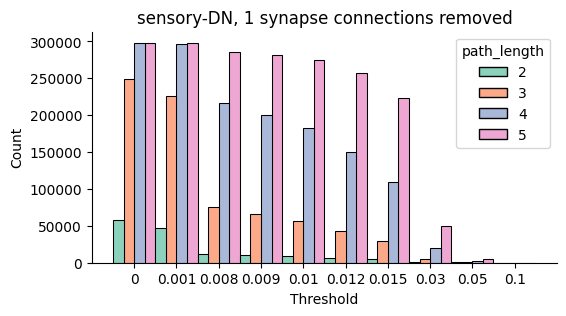

In [10]:
# number of paths between 1000 pre, and 1000 post neurons 
plt.figure(figsize=(6,3))
p = sns.histplot(
    ad_result_thre1_long[ad_result_thre1_long.value], x="threshold", hue="path_length", multiple="dodge"
)
# plt.yscale('log')
plt.xlabel("Threshold")
plt.title('sensory-DN, 1 synapse connections removed')
# remove upper and right borders
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

### sensory-DN, ad, many thresholds

In [11]:
# 1000 pre, 1000 post type_sides, for 4 path lengths 
ad_result_thre = pd.read_csv("ad_sensory_dn_thresholds.csv") # too big to put on github, available on request 
ad_result_thre.fillna(0, inplace=True)
ad_result_thre['path_length'] = ad_result_thre['plen'].astype(str)
ad_result_thre["path_length"] = pd.Categorical(
    ad_result_thre["path_length"], 
    categories=["2", "3", "4", "5"], 
    ordered=True
)
ad_result_thre

,pre,post,plen,threshold_0,threshold_0.001,threshold_0.008,threshold_0.009,threshold_0.01,threshold_0.012,threshold_0.015,threshold_0.03,threshold_0.05,threshold_0.1,path_length
0,ORN_VM7v_left,DNpe031_right,2,False,False,False,False,False,False,False,False,False,False,2
1,ORN_VM7v_left,DNpe031_right,3,True,True,False,False,False,False,False,False,False,False,3
2,ORN_VM7v_left,DNpe031_right,4,True,True,True,True,False,False,False,False,False,False,4
3,ORN_VM7v_left,DNpe031_right,5,True,True,True,True,True,True,False,False,False,False,5
4,ORN_VM7v_left,DNge093_left,2,False,False,False,False,False,False,False,False,False,False,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1199251,JO-EDM_left,DNp51_right,5,True,True,True,True,True,True,True,True,False,False,5
1199252,JO-EDM_left,DNg42_left,2,True,True,False,False,False,False,False,False,False,False,2
1199253,JO-EDM_left,DNg42_left,3,True,True,True,True,True,True,True,False,False,False,3
1199254,JO-EDM_left,DNg42_left,4,True,True,True,True,True,True,True,True,False,False,4


In [12]:
# make longer: all columns starting with 'threshold'
ad_result_thre_long = ad_result_thre.melt(id_vars=['path_length', 'pre','post'], value_vars=[col for col in ad_result_thre.columns if col.startswith('threshold')], var_name='threshold', value_name='value')
ad_result_thre_long['threshold'] = ad_result_thre_long['threshold'].str.replace('threshold_','')
ad_result_thre_long

,path_length,pre,post,threshold,value
0,2,ORN_VM7v_left,DNpe031_right,0,False
1,3,ORN_VM7v_left,DNpe031_right,0,True
2,4,ORN_VM7v_left,DNpe031_right,0,True
3,5,ORN_VM7v_left,DNpe031_right,0,True
4,2,ORN_VM7v_left,DNge093_left,0,False
...,...,...,...,...,...
11992555,5,JO-EDM_left,DNp51_right,0.1,False
11992556,2,JO-EDM_left,DNg42_left,0.1,False
11992557,3,JO-EDM_left,DNg42_left,0.1,False
11992558,4,JO-EDM_left,DNg42_left,0.1,False


In [13]:
ad_result_thre_long[['pre','post']].nunique()

pre     321
post    934
dtype: int64

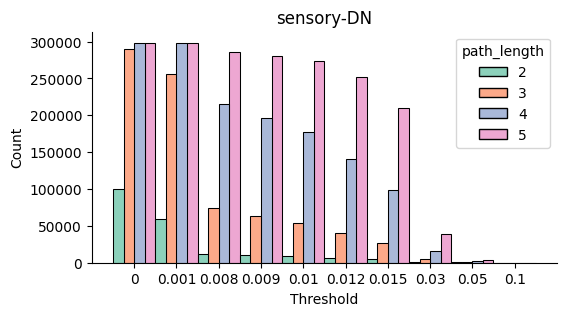

In [14]:
# number of paths between 1000 pre, and 1000 post neurons 
plt.figure(figsize=(6,3))
p = sns.histplot(
    ad_result_thre_long[ad_result_thre_long.value], x="threshold", hue="path_length", multiple="dodge"
)
# plt.yscale('log')
plt.xlabel("Threshold")
plt.title('sensory-DN')
# remove upper and right borders
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

### sensory-DN, ad

In [3]:
# 1000 pre, 1000 post type_sides, for 4 path lengths 
ad_result = pd.read_csv("full_ad_results.csv") # too big to put on github, available on request 
ad_result.fillna(0, inplace=True)
ad_result['path_length'] = ad_result['plen'].astype(str)
ad_result["path_length"] = pd.Categorical(
    ad_result["path_length"], 
    categories=["2", "3", "4", "5"], 
    ordered=True
)
ad_result

,pre,post,plen,threshold_0,effconn_0,threshold_0.001,threshold_0.01,threshold_0.03,threshold_0.05,threshold_0.1,effconn_0.01,effconn_0.05,path_length
0,DNx02_right,DNp57_right,2,True,1.292922e-05,True,False,False,False,False,0.000000e+00,0.0,2
1,DNx02_right,DNp57_right,3,True,2.705873e-05,True,False,False,False,False,0.000000e+00,0.0,3
2,DNx02_right,DNp57_right,4,True,4.696945e-05,True,True,False,False,False,7.231300e-06,0.0,4
3,DNx02_right,DNp57_right,5,True,3.586773e-05,True,True,False,False,False,3.829362e-06,0.0,5
4,DNx02_right,DNge082_right,2,True,7.605542e-05,True,False,False,False,False,0.000000e+00,0.0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1158155,HBeyelet_left,DNxl114_right,5,True,2.036250e-06,True,True,False,False,False,1.528620e-07,0.0,5
1158156,HBeyelet_left,DNg103_right,2,False,0.000000e+00,False,False,False,False,False,0.000000e+00,0.0,2
1158157,HBeyelet_left,DNg103_right,3,True,1.799564e-08,False,False,False,False,False,0.000000e+00,0.0,3
1158158,HBeyelet_left,DNg103_right,4,True,9.558164e-06,True,True,False,False,False,7.999396e-08,0.0,4


In [4]:
# make longer: all columns starting with 'threshold'
ad_result_long = ad_result.melt(id_vars=['path_length', 'effconn_0','pre','post'], value_vars=[col for col in ad_result.columns if col.startswith('threshold')], var_name='threshold', value_name='value')
ad_result_long['threshold'] = ad_result_long['threshold'].str.replace('threshold_','')
ad_result_long

,path_length,effconn_0,pre,post,threshold,value
0,2,1.292922e-05,DNx02_right,DNp57_right,0,True
1,3,2.705873e-05,DNx02_right,DNp57_right,0,True
2,4,4.696945e-05,DNx02_right,DNp57_right,0,True
3,5,3.586773e-05,DNx02_right,DNp57_right,0,True
4,2,7.605542e-05,DNx02_right,DNge082_right,0,True
...,...,...,...,...,...,...
6948955,5,2.036250e-06,HBeyelet_left,DNxl114_right,0.1,False
6948956,2,0.000000e+00,HBeyelet_left,DNg103_right,0.1,False
6948957,3,1.799564e-08,HBeyelet_left,DNg103_right,0.1,False
6948958,4,9.558164e-06,HBeyelet_left,DNg103_right,0.1,False


In [5]:
ad_result_long[['pre','post']].nunique()

pre     310
post    934
dtype: int64

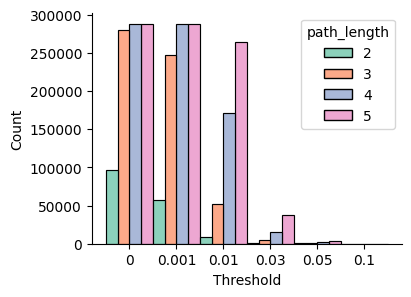

In [6]:
# number of paths between 1000 pre, and 1000 post neurons 
plt.figure(figsize=(4,3))
p = sns.histplot(
    ad_result_long[ad_result_long.value], x="threshold", hue="path_length", multiple="dodge"
)
# plt.yscale('log')
plt.xlabel("Threshold")
# remove upper and right borders
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

In [7]:
# numbers in the plot above 
ad_result_long[ad_result_long.value][["path_length", "threshold"]].value_counts()

path_length  threshold
5            0.001        288300
             0            288300
4            0            288300
             0.001        288075
3            0            279904
5            0.01         263739
3            0.001        247310
4            0.01         170754
2            0             96108
             0.001         56826
3            0.01          52242
5            0.03          37777
4            0.03          15643
2            0.01           8682
3            0.03           4876
5            0.05           3616
4            0.05           1759
2            0.03           1335
3            0.05            763
2            0.05            354
5            0.1              69
4            0.1              44
2            0.1              30
3            0.1              18
Name: count, dtype: int64

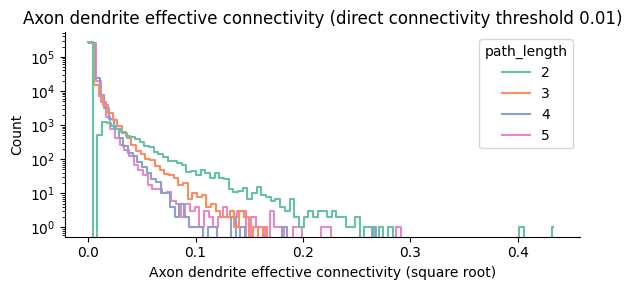

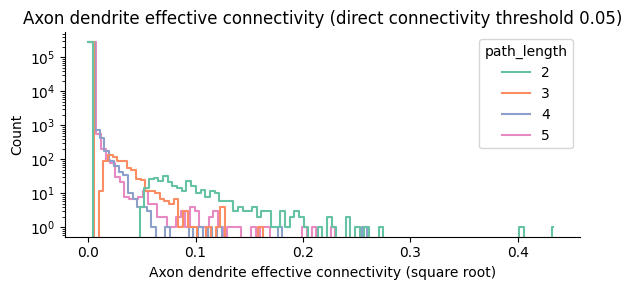

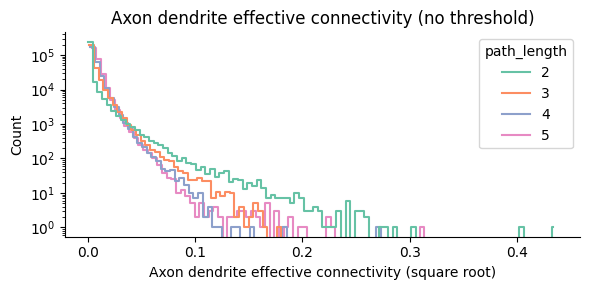

In [8]:
effconn_cols = ["effconn_0.01", "effconn_0.05", "effconn_0"]
titles = ["Axon dendrite effective connectivity (direct connectivity threshold 0.01)", 
          "Axon dendrite effective connectivity (direct connectivity threshold 0.05)", 
          "Axon dendrite effective connectivity (no threshold)"]

for col, title in zip(effconn_cols, titles):
    fig, ax = plt.subplots(figsize=(6, 3))
    
    plot_df = ad_result[ad_result[col].notna()].copy()
    plot_df["effconn_sqrt"] = np.sqrt(plot_df[col])
    
    sns.histplot(
        data=plot_df,
        x="effconn_sqrt",
        hue="path_length",
        bins=100,
        multiple="dodge",
        fill=False,
        element="step",
        ax=ax,
        # legend=False
    )
    ax.set_yscale("log")
    ax.set_xlabel("Axon dendrite effective connectivity (square root)")
    ax.set_title(title)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    # sns.move_legend(ax, loc="upper right", title="Path length")
    
    plt.tight_layout()
    plt.show()

## sensory-DN, not ad split

In [35]:
# 1000 pre, 1000 post type_sides, for 4 path lengths 
sd_result = pd.read_csv("sensory_dn_results.csv") # too big to put on github, available on request 
sd_result.fillna(0, inplace=True)
sd_result['path_length'] = sd_result['plen'].astype(str)
sd_result["path_length"] = pd.Categorical(
    sd_result["path_length"], 
    categories=["2", "3", "4", "5"], 
    ordered=True
)
sd_result

,pre,post,plen,threshold_0,effconn_0,threshold_0.001,threshold_0.01,threshold_0.03,threshold_0.05,threshold_0.1,effconn_0.01,effconn_0.05,path_length
0,ORN_VC5_left,DNpe053_left,2,True,0.000002,False,False,False,False,False,0.000000e+00,0.0,2
1,ORN_VC5_left,DNpe053_left,3,True,0.000006,True,False,False,False,False,0.000000e+00,0.0,3
2,ORN_VC5_left,DNpe053_left,4,True,0.000023,True,False,False,False,False,0.000000e+00,0.0,4
3,ORN_VC5_left,DNpe053_left,5,True,0.000055,True,True,False,False,False,1.909470e-07,0.0,5
4,ORN_VC5_left,DNp53_left,2,False,0.000000,False,False,False,False,False,0.000000e+00,0.0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1158155,LN-DN1_left,DNxl114_right,5,True,0.000170,True,True,True,False,False,5.546873e-05,0.0,5
1158156,LN-DN1_left,DNg103_right,2,False,0.000000,False,False,False,False,False,0.000000e+00,0.0,2
1158157,LN-DN1_left,DNg103_right,3,True,0.000016,True,True,False,False,False,3.770857e-06,0.0,3
1158158,LN-DN1_left,DNg103_right,4,True,0.000070,True,True,False,False,False,2.050286e-05,0.0,4


In [36]:
# make longer: all columns starting with 'threshold'
sd_result_long = sd_result.melt(id_vars=['path_length', 'effconn_0','pre','post'], value_vars=[col for col in sd_result.columns if col.startswith('threshold')], var_name='threshold', value_name='value')
sd_result_long['threshold'] = sd_result_long['threshold'].str.replace('threshold_','')
sd_result_long

,path_length,effconn_0,pre,post,threshold,value
0,2,0.000002,ORN_VC5_left,DNpe053_left,0,True
1,3,0.000006,ORN_VC5_left,DNpe053_left,0,True
2,4,0.000023,ORN_VC5_left,DNpe053_left,0,True
3,5,0.000055,ORN_VC5_left,DNpe053_left,0,True
4,2,0.000000,ORN_VC5_left,DNp53_left,0,False
...,...,...,...,...,...,...
6948955,5,0.000170,LN-DN1_left,DNxl114_right,0.1,False
6948956,2,0.000000,LN-DN1_left,DNg103_right,0.1,False
6948957,3,0.000016,LN-DN1_left,DNg103_right,0.1,False
6948958,4,0.000070,LN-DN1_left,DNg103_right,0.1,False


In [37]:
sd_result_long[['pre','post']].nunique()

pre     310
post    934
dtype: int64

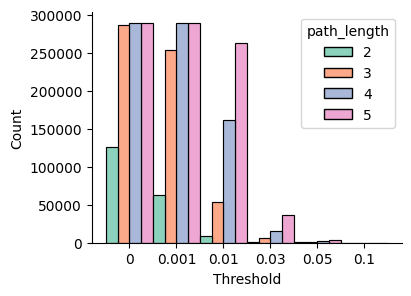

In [38]:
# number of paths between 1000 pre, and 1000 post neurons 
plt.figure(figsize=(4,3))
p = sns.histplot(
    sd_result_long[sd_result_long.value], x="threshold", hue="path_length", multiple="dodge"
)
# plt.yscale('log')
plt.xlabel("Threshold")
# remove upper and right borders
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

In [39]:
# numbers in the plot above 
sd_result_long[sd_result_long.value][["path_length", "threshold"]].value_counts()

path_length  threshold
5            0.001        289540
             0            289540
4            0            289534
             0.001        289410
3            0            286456
5            0.01         263085
3            0.001        253463
4            0.01         161580
2            0            126423
             0.001         63350
3            0.01          54180
5            0.03          36621
4            0.03          15873
2            0.01           9375
3            0.03           5656
5            0.05           4107
4            0.05           2134
2            0.03           1591
3            0.05           1084
2            0.05            426
5            0.1             134
4            0.1             117
3            0.1             111
2            0.1              87
Name: count, dtype: int64

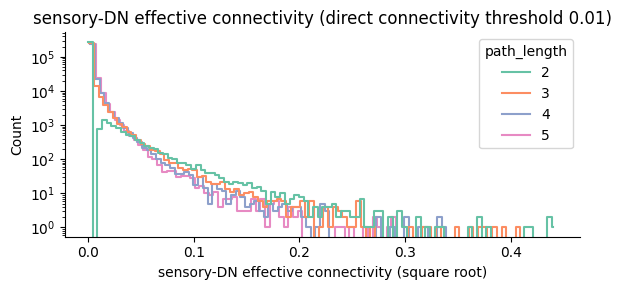

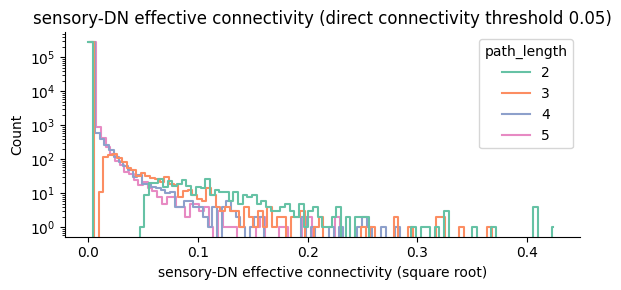

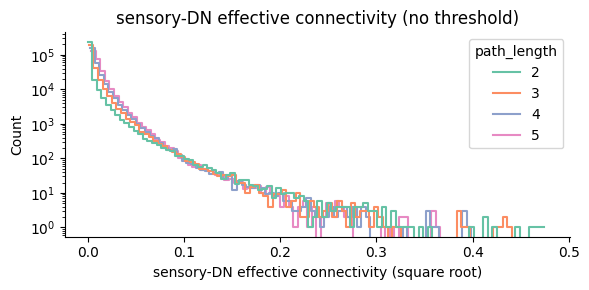

In [41]:
effconn_cols = ["effconn_0.01", "effconn_0.05", "effconn_0"]
titles = ["sensory-DN effective connectivity (direct connectivity threshold 0.01)", 
          "sensory-DN effective connectivity (direct connectivity threshold 0.05)", 
          "sensory-DN effective connectivity (no threshold)"]

for col, title in zip(effconn_cols, titles):
    fig, ax = plt.subplots(figsize=(6, 3))
    
    plot_df = sd_result[sd_result[col].notna()].copy()
    plot_df["effconn_sqrt"] = np.sqrt(plot_df[col])
    
    sns.histplot(
        data=plot_df,
        x="effconn_sqrt",
        hue="path_length",
        bins=100,
        multiple="dodge",
        fill=False,
        element="step",
        ax=ax,
        # legend=False
    )
    ax.set_yscale("log")
    ax.set_xlabel("sensory-DN effective connectivity (square root)")
    ax.set_title(title)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    # sns.move_legend(ax, loc="upper right", title="Path length")
    
    plt.tight_layout()
    plt.show()

In [67]:
ad0 = ad_result_long[ad_result_long.threshold == '0']
ad0['ad_split'] = 'ad_split'
sd0 = sd_result_long[sd_result_long.threshold == '0']
sd0['ad_split'] = 'not_split'
adsd_long = pd.concat([ad0, sd0], ignore_index=True)
adsd_long

/tmp/ipykernel_278404/2024968183.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipykernel_278404/2024968183.py:4: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,path_length,effconn_0,pre,post,threshold,value,ad_split
0,2,0.000013,DNx02_right,DNp57_right,0,True,ad_split
1,3,0.000027,DNx02_right,DNp57_right,0,True,ad_split
2,4,0.000047,DNx02_right,DNp57_right,0,True,ad_split
3,5,0.000036,DNx02_right,DNp57_right,0,True,ad_split
4,2,0.000076,DNx02_right,DNge082_right,0,True,ad_split
...,...,...,...,...,...,...,...
2316315,5,0.000170,LN-DN1_left,DNxl114_right,0,True,not_split
2316316,2,0.000000,LN-DN1_left,DNg103_right,0,False,not_split
2316317,3,0.000016,LN-DN1_left,DNg103_right,0,True,not_split
2316318,4,0.000070,LN-DN1_left,DNg103_right,0,True,not_split


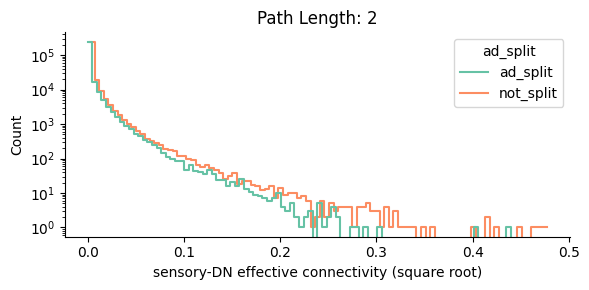

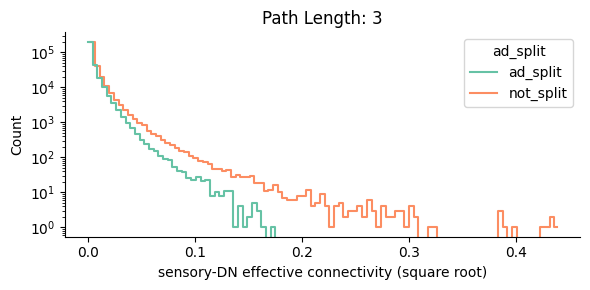

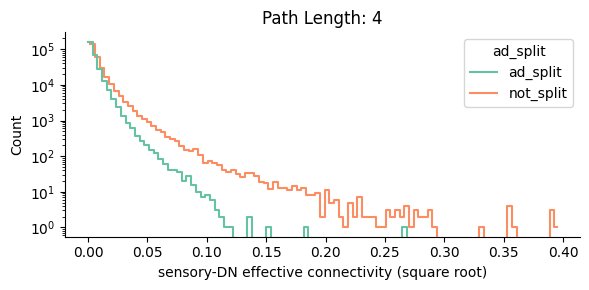

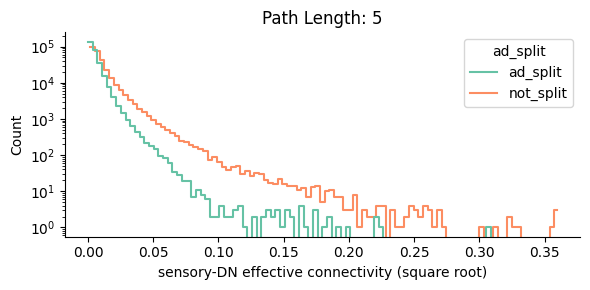

In [70]:
for plen in adsd_long.path_length.unique():
    fig, ax = plt.subplots(figsize=(6, 3))
        
    plot_df = adsd_long[adsd_long['effconn_0'].notna() & (adsd_long['path_length'] == plen)].copy()
    plot_df["effconn_sqrt"] = np.sqrt(plot_df['effconn_0'])

    sns.histplot(
        data=plot_df,
        x="effconn_sqrt",
        hue="ad_split",
        bins=100,
        multiple="dodge",
        fill=False,
        element="step",
        ax=ax,
        # legend=False
    )
    ax.set_yscale("log")
    ax.set_xlabel("sensory-DN effective connectivity (square root)")
    ax.set_title(f"Path Length: {plen}")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    # sns.move_legend(ax, loc="upper right", title="Path length")

    plt.tight_layout()
    plt.show()

In [98]:
from scipy.sparse.linalg import eigs
vals, vecs = eigs(inprop, k=3, which='LR')
vals_ad, vecs_ad = eigs(ad_inprop, k=3, which='LR')
vals, vals_ad

(array([0.999859  +0.j, 1.000001  +0.j, 0.99999946+0.j], dtype=complex64),
 array([0.99999917+0.j, 0.9661007 +0.j, 0.9083811 +0.j], dtype=complex64))

In [100]:
# number of neurons with no incoming connections
print(f"  inprop:    {(inprop.sum(axis=0) == 0).sum()}")
print(f"  ad_inprop: {(ad_inprop.sum(axis=0) == 0).sum()}")

  inprop:    162
  ad_inprop: 18972


From Claude Sonnet 4.6: If column sums are all ≤ 1, then your matrices are column sub-stochastic, and there's a clean theorem:
For a non-negative column sub-stochastic matrix, ρ(A) ≤ 1 always. More specifically, ρ(A) equals the spectral radius of the largest strongly connected component, and it will be < 1 if any probability "leaks out" (columns summing to < 1).
So the spectral radius alone won't distinguish your matrices much — both will have ρ ≤ 1, likely close to 1. The decay you're seeing across path lengths is governed by how quickly probability leaks, which is related to the second largest eigenvalue (the spectral gap).

So the 18,972 zero column-sum neurons in ad_inprop are sensories (or near-sensories) that act as sources only — paths can start from them but can never be reached through a longer path.

## full connectome

In [9]:
# 1000 pre, 1000 post type_sides, for 4 path lengths 
result = pd.read_csv("full_results.csv") # too big to put on github, available on request 
result.fillna(0, inplace=True)
result

,pre,post,plen,threshold_0,threshold_0.001,threshold_0.01,threshold_0.03,threshold_0.05,threshold_0.1,effconn
0,AVLP169_right,CB0906_right,2,False,False,False,False,False,False,0.000000e+00
1,AVLP169_right,CB0906_right,3,True,True,False,False,False,False,2.329226e-07
2,AVLP169_right,CB0906_right,4,True,True,False,False,False,False,1.254350e-06
3,AVLP169_right,CB0906_right,5,True,True,True,False,False,False,3.028013e-06
4,AVLP169_right,CB3126_left,2,False,False,False,False,False,False,0.000000e+00
...,...,...,...,...,...,...,...,...,...,...
3999995,AN_GNG_32_right,CB1676_left,5,True,True,True,False,False,False,2.438331e-06
3999996,AN_GNG_32_right,CB3343_right,2,False,False,False,False,False,False,0.000000e+00
3999997,AN_GNG_32_right,CB3343_right,3,True,True,False,False,False,False,7.366973e-06
3999998,AN_GNG_32_right,CB3343_right,4,True,True,False,False,False,False,1.064111e-05


In [10]:
# make longer: all columns starting with 'threshold'
result_long = result.melt(id_vars=['plen', 'effconn','pre','post'], value_vars=[col for col in result.columns if col.startswith('threshold')], var_name='threshold', value_name='value')
result_long['threshold'] = result_long['threshold'].str.replace('threshold_','')
result_long['path_length'] = result_long['plen'].astype(str)
result_long["path_length"] = pd.Categorical(
    result_long["path_length"], 
    categories=["2", "3", "4", "5"], 
    ordered=True
)
result_long

,plen,effconn,pre,post,threshold,value,path_length
0,2,0.000000e+00,AVLP169_right,CB0906_right,0,False,2
1,3,2.329226e-07,AVLP169_right,CB0906_right,0,True,3
2,4,1.254350e-06,AVLP169_right,CB0906_right,0,True,4
3,5,3.028013e-06,AVLP169_right,CB0906_right,0,True,5
4,2,0.000000e+00,AVLP169_right,CB3126_left,0,False,2
...,...,...,...,...,...,...,...
23999995,5,2.438331e-06,AN_GNG_32_right,CB1676_left,0.1,False,5
23999996,2,0.000000e+00,AN_GNG_32_right,CB3343_right,0.1,False,2
23999997,3,7.366973e-06,AN_GNG_32_right,CB3343_right,0.1,False,3
23999998,4,1.064111e-05,AN_GNG_32_right,CB3343_right,0.1,False,4


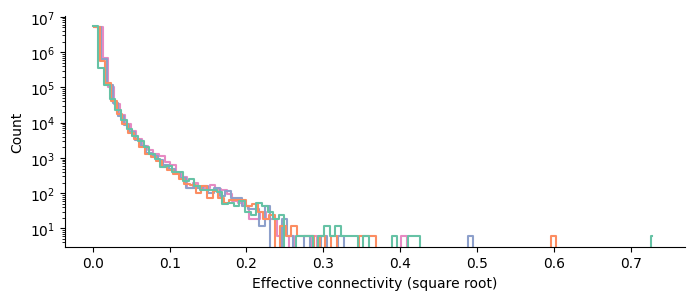

In [11]:
result_long["effconn_sqrt"] = np.sqrt(result_long["effconn"])

plt.figure(figsize=(8,3))
sns.histplot(
    data=result_long[result_long.effconn.notna()],
    x="effconn_sqrt",
    hue="path_length",
    bins=100,
    multiple="dodge",
    fill=False, 
    element="step",
    legend=False
)
plt.yscale("log")
plt.xlabel("Effective connectivity (square root)")
# remove upper and right borders
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

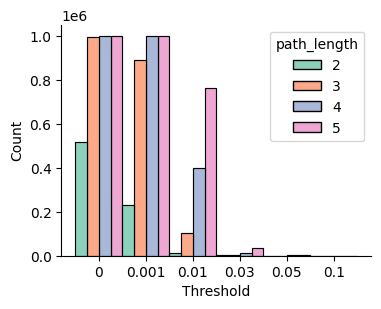

In [12]:
# number of paths between 1000 pre, and 1000 post neurons 
plt.figure(figsize=(4,3))
p = sns.histplot(
    result_long[result_long.value], x="threshold", hue="path_length", multiple="dodge"
)
# plt.yscale('log')
plt.xlabel("Threshold")
# remove upper and right borders
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

In [13]:
# numbers in the plot above 
result_long[result_long.value][["path_length", "threshold"]].value_counts()

path_length  threshold
5            0            1000000
             0.001         999982
4            0             999972
             0.001         998353
3            0             992669
             0.001         888924
5            0.01          760192
2            0             517414
4            0.01          400361
2            0.001         231573
3            0.01          103861
5            0.03           35328
4            0.03           13874
2            0.01           13655
3            0.03            4646
5            0.05            3112
4            0.05            1778
2            0.03            1264
3            0.05             908
2            0.05             355
5            0.1              113
4            0.1               90
3            0.1               66
2            0.1               50
Name: count, dtype: int64

### effconn - threshold

In [14]:
threshold_effconn = pd.read_csv("custom_effconn_results.csv") 
threshold_effconn.fillna(0, inplace=True)
threshold_effconn = threshold_effconn.merge(result, on=['pre','post','plen','threshold_0','threshold_0.001','threshold_0.01','threshold_0.03','threshold_0.05','threshold_0.1'])
threshold_effconn['plen'] = threshold_effconn['plen'].astype(str)
threshold_effconn["plen"] = pd.Categorical(
    threshold_effconn["plen"], 
    categories=["2", "3", "4", "5"], 
    ordered=True
)
threshold_effconn

,pre,post,plen,threshold_0,threshold_0.001,threshold_0.01,effconn_0.01,threshold_0.03,threshold_0.05,effconn_0.05,threshold_0.1,effconn
0,CB2140_right,CB0906_right,2,False,False,False,0.000000e+00,False,False,0.0,False,0.000000e+00
1,CB2140_right,CB0906_right,3,True,False,False,0.000000e+00,False,False,0.0,False,3.145974e-08
2,CB2140_right,CB0906_right,4,True,True,False,0.000000e+00,False,False,0.0,False,3.497424e-07
3,CB2140_right,CB0906_right,5,True,True,False,0.000000e+00,False,False,0.0,False,1.003508e-06
4,CB2140_right,CB3126_left,2,False,False,False,0.000000e+00,False,False,0.0,False,0.000000e+00
...,...,...,...,...,...,...,...,...,...,...,...,...
3999995,SMP014_left,CB1676_left,5,True,True,True,4.893915e-09,False,False,0.0,False,4.212947e-06
3999996,SMP014_left,CB3343_right,2,True,False,False,0.000000e+00,False,False,0.0,False,2.880823e-07
3999997,SMP014_left,CB3343_right,3,True,True,False,0.000000e+00,False,False,0.0,False,2.935215e-06
3999998,SMP014_left,CB3343_right,4,True,True,True,3.729174e-07,False,False,0.0,False,8.564004e-06


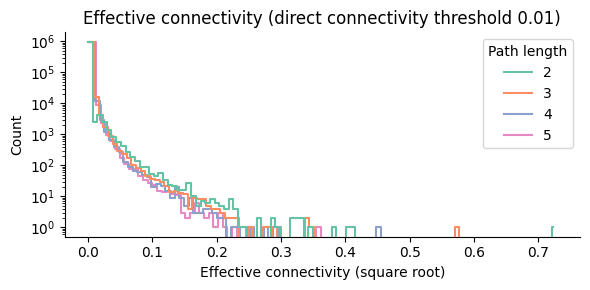

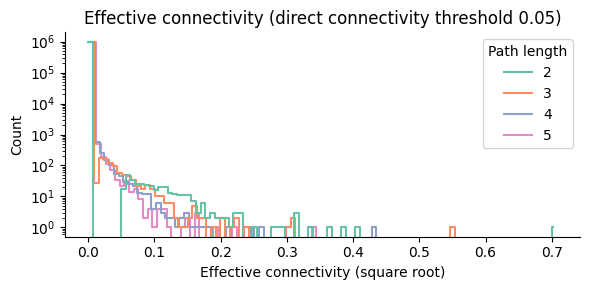

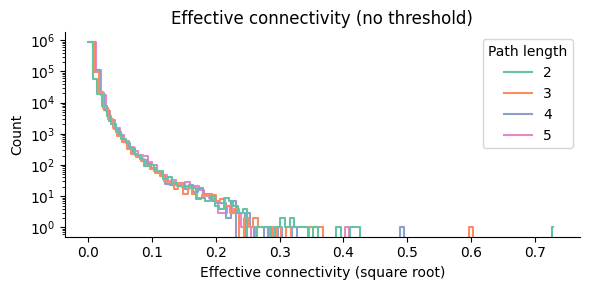

In [15]:
effconn_cols = ["effconn_0.01", "effconn_0.05", "effconn"]
titles = ["Effective connectivity (direct connectivity threshold 0.01)", 
          "Effective connectivity (direct connectivity threshold 0.05)", 
          "Effective connectivity (no threshold)"]

for col, title in zip(effconn_cols, titles):
    fig, ax = plt.subplots(figsize=(6, 3))
    
    plot_df = threshold_effconn[threshold_effconn[col].notna()].copy()
    plot_df["effconn_sqrt"] = np.sqrt(plot_df[col])
    
    sns.histplot(
        data=plot_df,
        x="effconn_sqrt",
        hue="plen",
        bins=100,
        multiple="dodge",
        fill=False,
        element="step",
        ax=ax,
    )
    ax.set_yscale("log")
    ax.set_xlabel("Effective connectivity (square root)")
    ax.set_title(title)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    sns.move_legend(ax, loc="upper right", title="Path length")
    
    plt.tight_layout()
    plt.show()

# number of paths

## ad

In [16]:
# number of paths between 100 pre and 100 post type-sides, for 4 path lengths 
# NOTE: calculated after thresholding direct connectivity at 0.01
ad_npath = pd.read_csv('npath_ad_0.01_results.csv')
ad_npath['npaths_loop_diff'] = ad_npath['n_paths'] - ad_npath['n_paths_noloop']
ad_npath['loop_frac'] = ad_npath.npaths_loop_diff / ad_npath.n_paths
ad_npath

,pre,post,plen,threshold_0,n_paths,n_paths_noloop,threshold_0.001,threshold_0.01,threshold_0.03,threshold_0.05,threshold_0.1,npaths_loop_diff,loop_frac
0,PhG14_right,DNpe053_left,2,False,0,0,False,False,False,False,False,0,NaN
1,PhG14_right,DNpe053_left,3,False,0,0,False,False,False,False,False,0,NaN
2,PhG14_right,DNpe053_left,4,True,1,1,True,True,False,False,False,0,0.000000
3,PhG14_right,DNpe053_left,5,True,37,37,True,True,True,False,False,0,0.000000
4,PhG14_right,DNp53_left,2,False,0,0,False,False,False,False,False,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1158155,CB4147_left,DNxl114_right,5,True,194,194,True,True,True,False,False,0,0.000000
1158156,CB4147_left,DNg103_right,2,True,1,1,True,True,True,True,False,0,0.000000
1158157,CB4147_left,DNg103_right,3,False,0,0,False,False,False,False,False,0,NaN
1158158,CB4147_left,DNg103_right,4,True,16,15,True,True,False,False,False,1,0.062500


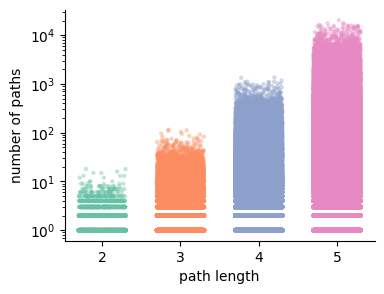

In [17]:
np.random.seed(0)
# same color order as your rcParams cycle 
palette = dict(zip([2, 3, 4, 5], plt.rcParams["axes.prop_cycle"].by_key()["color"][:4]))

jitter = 0.3
x = ad_npath["plen"].to_numpy()
y = ad_npath["n_paths"].to_numpy()

x_jittered = x + np.random.uniform(-jitter, jitter, size=len(x))

plt.figure(figsize=(4,3))
plt.scatter(x_jittered, y, c=ad_npath['plen'].astype(int).map(palette), alpha=0.3, s=5)
plt.xlabel("path length")
plt.ylabel("number of paths")
plt.yscale("log")
# force integer ticks on x-axis
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))

# remove upper and right borders
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.show()


In [18]:
ad_npath.groupby('plen')['n_paths'].quantile([0.25, 0.5, 0.75])

plen      
2     0.25     0.0
      0.50     0.0
      0.75     0.0
3     0.25     0.0
      0.50     0.0
      0.75     0.0
4     0.25     0.0
      0.50     0.0
      0.75     3.0
5     0.25     2.0
      0.50    16.0
      0.75    71.0
Name: n_paths, dtype: float64

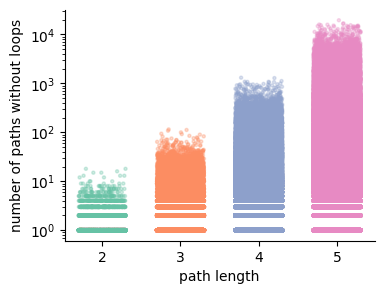

In [19]:
np.random.seed(0)

jitter = 0.3
x = ad_npath["plen"].to_numpy()
y = ad_npath["n_paths_noloop"].to_numpy()

x_jittered = x + np.random.uniform(-jitter, jitter, size=len(x))

plt.figure(figsize=(4,3))
plt.scatter(x_jittered, y, alpha=0.3, s=5, c=ad_npath['plen'].astype(int).map(palette))
plt.xlabel("path length")
plt.ylabel("number of paths without loops")
plt.yscale("log")
# force integer ticks on x-axis
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))

# remove upper and right borders
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.show()


In [20]:
ad_npath.groupby('plen')['n_paths_noloop'].quantile([0.25, 0.5, 0.75])

plen      
2     0.25     0.0
      0.50     0.0
      0.75     0.0
3     0.25     0.0
      0.50     0.0
      0.75     0.0
4     0.25     0.0
      0.50     0.0
      0.75     3.0
5     0.25     2.0
      0.50    16.0
      0.75    70.0
Name: n_paths_noloop, dtype: float64

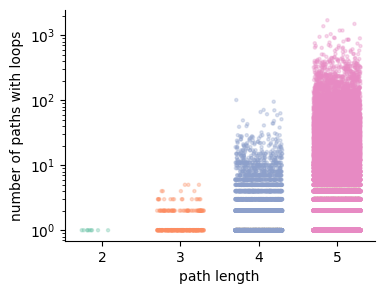

In [21]:
np.random.seed(0)

jitter = 0.3
x = ad_npath["plen"].to_numpy()
y = ad_npath["npaths_loop_diff"].to_numpy()

x_jittered = x + np.random.uniform(-jitter, jitter, size=len(x))

plt.figure(figsize=(4,3))
plt.scatter(x_jittered, y, alpha=0.3, s=5, c=ad_npath['plen'].astype(int).map(palette))
plt.xlabel("path length")
plt.ylabel("number of paths with loops")
plt.yscale("log")
# force integer ticks on x-axis
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))

# remove upper and right borders
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.show()


In [22]:
ad_npath.groupby('plen')['npaths_loop_diff'].quantile([0.25, 0.5, 0.75])

plen      
2     0.25    0.0
      0.50    0.0
      0.75    0.0
3     0.25    0.0
      0.50    0.0
      0.75    0.0
4     0.25    0.0
      0.50    0.0
      0.75    0.0
5     0.25    0.0
      0.50    0.0
      0.75    0.0
Name: npaths_loop_diff, dtype: float64

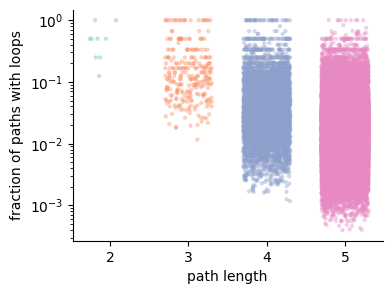

In [23]:
np.random.seed(0)

jitter = 0.3
x = ad_npath["plen"].to_numpy()
y = ad_npath["loop_frac"].to_numpy()

x_jittered = x + np.random.uniform(-jitter, jitter, size=len(x))

plt.figure(figsize=(4,3))
plt.scatter(x_jittered, y, alpha=0.3, s=5, c=ad_npath['plen'].astype(int).map(palette))
plt.xlabel("path length")
plt.ylabel("fraction of paths with loops")
plt.yscale("log")
# force integer ticks on x-axis
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))

# remove upper and right borders
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.show()

In [24]:
ad_npath = ad_npath.merge(ad_result, on =['pre','post','plen'], suffixes=('_filter', ''))
ad_npath['effconn_per_path'] = ad_npath['effconn_0.01'] / ad_npath.n_paths

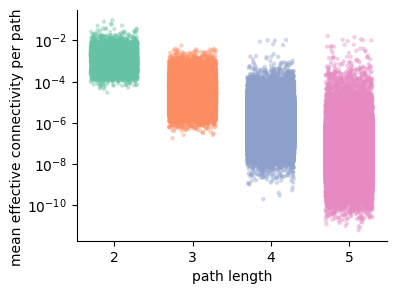

In [25]:
np.random.seed(0)

jitter = 0.3
x = ad_npath["plen"].astype(int).to_numpy()
y = ad_npath["effconn_per_path"].to_numpy()

x_jittered = x + np.random.uniform(-jitter, jitter, size=len(x))

plt.figure(figsize=(4,3))
plt.scatter(x_jittered, y, alpha=0.3, s=5, c=ad_npath['plen'].astype(int).map(palette))
plt.xlabel("path length")
plt.ylabel("mean effective connectivity per path")
plt.gca().yaxis.set_label_coords(-0.17, 0.45)
plt.yscale("log")
# force integer ticks on x-axis
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))

# remove upper and right borders
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.show()


## full connectome - threshold 0.01

In [ ]:
# number of paths between 100 pre and 100 post type-sides, for 4 path lengths 
# NOTE: calculated after thresholding direct connectivity at 0.01
full_thre_npath = pd.read_csv('npath_0.01_results.csv')
full_thre_npath['npaths_loop_diff'] = full_thre_npath['n_paths'] - full_thre_npath['n_paths_noloop']
full_thre_npath['loop_frac'] = full_thre_npath.npaths_loop_diff / full_thre_npath.n_paths
full_thre_npath

,pre,post,plen,threshold_0,n_paths,n_paths_noloop,threshold_0.001,threshold_0.01,threshold_0.03,threshold_0.05,threshold_0.1,npaths_loop_diff,loop_frac
0,ORN_DM5_right,DNpe053_left,2,False,0,0,False,False,False,False,False,0,NaN
1,ORN_DM5_right,DNpe053_left,3,False,0,0,False,False,False,False,False,0,NaN
2,ORN_DM5_right,DNpe053_left,4,False,0,0,False,False,False,False,False,0,NaN
3,ORN_DM5_right,DNpe053_left,5,False,0,0,False,False,False,False,False,0,NaN
4,ORN_DM5_right,DNp53_left,2,False,0,0,False,False,False,False,False,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1158155,ORN_VC3_right,DNxl114_right,5,True,10,10,True,True,True,False,False,0,0.0
1158156,ORN_VC3_right,DNg103_right,2,False,0,0,False,False,False,False,False,0,NaN
1158157,ORN_VC3_right,DNg103_right,3,False,0,0,False,False,False,False,False,0,NaN
1158158,ORN_VC3_right,DNg103_right,4,False,0,0,False,False,False,False,False,0,NaN


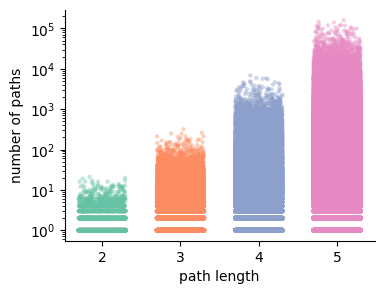

In [ ]:
np.random.seed(0)
# same color order as your rcParams cycle 
palette = dict(zip([2, 3, 4, 5], plt.rcParams["axes.prop_cycle"].by_key()["color"][:4]))

jitter = 0.3
x = full_thre_npath["plen"].to_numpy()
y = full_thre_npath["n_paths"].to_numpy()

x_jittered = x + np.random.uniform(-jitter, jitter, size=len(x))

plt.figure(figsize=(4,3))
plt.scatter(x_jittered, y, c=full_thre_npath['plen'].astype(int).map(palette), alpha=0.3, s=5)
plt.xlabel("path length")
plt.ylabel("number of paths")
plt.yscale("log")
# force integer ticks on x-axis
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))

# remove upper and right borders
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.show()


In [ ]:
full_thre_npath.groupby('plen')['n_paths'].quantile([0.25, 0.5, 0.75])

plen      
2     0.25      0.0
      0.50      0.0
      0.75      0.0
3     0.25      0.0
      0.50      0.0
      0.75      0.0
4     0.25      0.0
      0.50      0.0
      0.75      4.0
5     0.25      2.0
      0.50     16.0
      0.75    125.0
Name: n_paths, dtype: float64

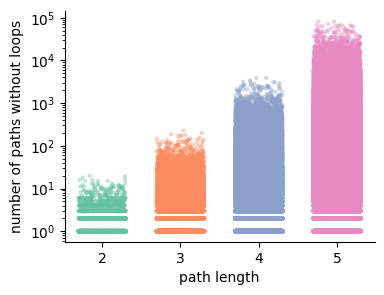

In [ ]:
np.random.seed(0)

jitter = 0.3
x = full_thre_npath["plen"].to_numpy()
y = full_thre_npath["n_paths_noloop"].to_numpy()

x_jittered = x + np.random.uniform(-jitter, jitter, size=len(x))

plt.figure(figsize=(4,3))
plt.scatter(x_jittered, y, alpha=0.3, s=5, c=full_thre_npath['plen'].astype(int).map(palette))
plt.xlabel("path length")
plt.ylabel("number of paths without loops")
plt.yscale("log")
# force integer ticks on x-axis
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))

# remove upper and right borders
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.show()


In [ ]:
full_thre_npath.groupby('plen')['n_paths_noloop'].quantile([0.25, 0.5, 0.75])

plen      
2     0.25      0.0
      0.50      0.0
      0.75      0.0
3     0.25      0.0
      0.50      0.0
      0.75      0.0
4     0.25      0.0
      0.50      0.0
      0.75      4.0
5     0.25      2.0
      0.50     15.0
      0.75    118.0
Name: n_paths_noloop, dtype: float64

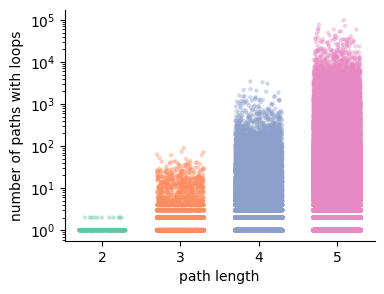

In [ ]:
np.random.seed(0)

jitter = 0.3
x = full_thre_npath["plen"].to_numpy()
y = full_thre_npath["npaths_loop_diff"].to_numpy()

x_jittered = x + np.random.uniform(-jitter, jitter, size=len(x))

plt.figure(figsize=(4,3))
plt.scatter(x_jittered, y, alpha=0.3, s=5, c=full_thre_npath['plen'].astype(int).map(palette))
plt.xlabel("path length")
plt.ylabel("number of paths with loops")
plt.yscale("log")
# force integer ticks on x-axis
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))

# remove upper and right borders
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.show()


In [ ]:
full_thre_npath.groupby('plen')['npaths_loop_diff'].quantile([0.25, 0.5, 0.75])

plen      
2     0.25    0.0
      0.50    0.0
      0.75    0.0
3     0.25    0.0
      0.50    0.0
      0.75    0.0
4     0.25    0.0
      0.50    0.0
      0.75    0.0
5     0.25    0.0
      0.50    0.0
      0.75    6.0
Name: npaths_loop_diff, dtype: float64

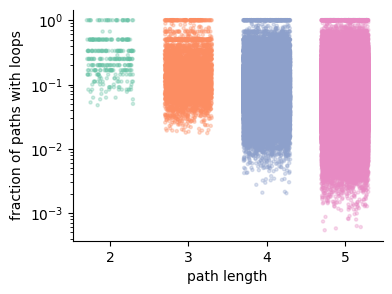

In [ ]:
np.random.seed(0)

jitter = 0.3
x = full_thre_npath["plen"].to_numpy()
y = full_thre_npath["loop_frac"].to_numpy()

x_jittered = x + np.random.uniform(-jitter, jitter, size=len(x))

plt.figure(figsize=(4,3))
plt.scatter(x_jittered, y, alpha=0.3, s=5, c=full_thre_npath['plen'].astype(int).map(palette))
plt.xlabel("path length")
plt.ylabel("fraction of paths with loops")
plt.yscale("log")
# force integer ticks on x-axis
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))

# remove upper and right borders
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.show()

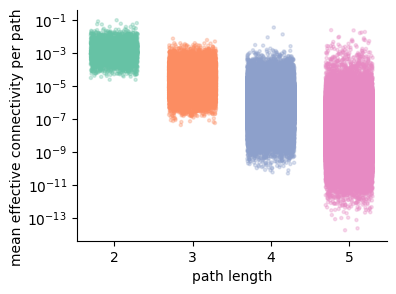

In [ ]:
# TODO change ad_result
full_thre_npath = full_thre_npath.merge(ad_result, on =['pre','post','plen'], suffixes=('_filter', ''))
full_thre_npath['effconn_per_path'] = full_thre_npath['effconn_0.01'] / full_thre_npath.n_paths
np.random.seed(0)

jitter = 0.3
x = full_thre_npath["plen"].astype(int).to_numpy()
y = full_thre_npath["effconn_per_path"].to_numpy()

x_jittered = x + np.random.uniform(-jitter, jitter, size=len(x))

plt.figure(figsize=(4,3))
plt.scatter(x_jittered, y, alpha=0.3, s=5, c=full_thre_npath['plen'].astype(int).map(palette))
plt.xlabel("path length")
plt.ylabel("mean effective connectivity per path")
plt.gca().yaxis.set_label_coords(-0.17, 0.45)
plt.yscale("log")
# force integer ticks on x-axis
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))

# remove upper and right borders
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.show()


## full connectome

In [35]:
# number of paths between 100 pre and 100 post type-sides, for 4 path lengths 
npath = pd.read_csv('results_npath.csv')
npath

,pre,post,plen,threshold_0,n_paths,threshold_0.001,threshold_0.01,threshold_0.03,threshold_0.05,threshold_0.1,effconn
0,LC33_right,CB0906_right,2,False,0,False,False,False,False,False,NaN
1,LC33_right,CB0906_right,3,True,0,True,False,False,False,False,5.216793e-07
2,LC33_right,CB0906_right,4,True,13702,True,False,False,False,False,2.160383e-06
3,LC33_right,CB0906_right,5,True,33733081,True,True,False,False,False,4.843183e-06
4,LC33_right,CB3126_left,2,True,0,False,False,False,False,False,6.463936e-07
...,...,...,...,...,...,...,...,...,...,...,...
39995,LC14b_left,CB2392_right,5,True,251487436,True,True,False,False,False,7.172086e-05
39996,LC14b_left,LHPV10c1_left,2,True,0,False,False,False,False,False,8.191339e-07
39997,LC14b_left,LHPV10c1_left,3,True,207,True,False,False,False,False,3.426039e-06
39998,LC14b_left,LHPV10c1_left,4,True,840477,True,False,False,False,False,5.587108e-06


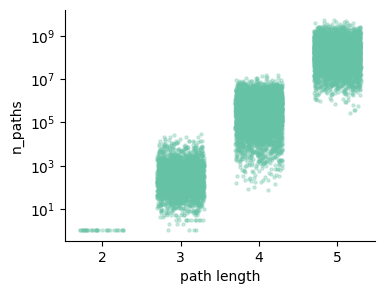

In [36]:
np.random.seed(0)

jitter = 0.3
x = npath["plen"].to_numpy()
y = npath["n_paths"].to_numpy()

x_jittered = x + np.random.uniform(-jitter, jitter, size=len(x))

plt.figure(figsize=(4,3))
plt.scatter(x_jittered, y, alpha=0.3, s=5)
plt.xlabel("path length")
plt.ylabel("n_paths")
plt.yscale("log")

# force integer ticks on x-axis
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))

# remove upper and right borders
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.show()


In [37]:
# 60 pre types, 100 post types, 4 path lengths 
noloop = pd.read_csv('noloop_results.csv')
noloop['npaths_loop_diff'] = noloop['n_paths'] - noloop['n_paths_noloop']
noloop['loop_frac'] = noloop.npaths_loop_diff / noloop.n_paths
noloop

,pre,post,plen,threshold_0,n_paths,n_paths_noloop,threshold_0.001,threshold_0.01,threshold_0.03,threshold_0.05,threshold_0.1,effconn,effconn_noloop,npaths_loop_diff,loop_frac
0,DNd04_left,CB0906_right,2,True,12,12,False,False,False,False,False,4.742473e-06,4.742473e-06,0,0.000000
1,DNd04_left,CB0906_right,3,True,3544,3544,True,False,False,False,False,2.679580e-05,2.679580e-05,0,0.000000
2,DNd04_left,CB0906_right,4,True,881577,875705,True,False,False,False,False,5.015441e-05,4.979766e-05,5872,0.006661
3,DNd04_left,CB0906_right,5,True,207393098,204517883,True,True,False,False,False,6.396395e-05,5.979337e-05,2875215,0.013864
4,DNd04_left,CB3126_left,2,True,30,30,True,False,False,False,False,1.151613e-04,1.151613e-04,0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23995,LHPV4a10_right,CB2392_right,5,True,6401615,6371035,True,False,False,False,False,2.726754e-07,2.708529e-07,30580,0.004777
23996,LHPV4a10_right,LHPV10c1_left,2,False,0,0,False,False,False,False,False,NaN,NaN,0,NaN
23997,LHPV4a10_right,LHPV10c1_left,3,True,877,876,True,False,False,False,False,1.140861e-05,1.140800e-05,1,0.001140
23998,LHPV4a10_right,LHPV10c1_left,4,True,457664,455082,True,True,False,False,False,1.873583e-05,1.850830e-05,2582,0.005642


In [38]:
# any pair where the only connections are those with loops? 
noloop[(noloop.n_paths != 0) & (noloop.n_paths_noloop == 0)]

,pre,post,plen,threshold_0,n_paths,n_paths_noloop,threshold_0.001,threshold_0.01,threshold_0.03,threshold_0.05,threshold_0.1,effconn,effconn_noloop,npaths_loop_diff,loop_frac


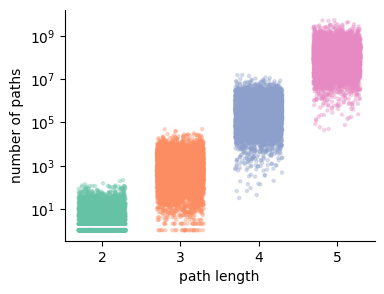

In [39]:
np.random.seed(0)
# same color order as your rcParams cycle 
palette = dict(zip([2, 3, 4, 5], plt.rcParams["axes.prop_cycle"].by_key()["color"][:4]))

jitter = 0.3
x = noloop["plen"].to_numpy()
y = noloop["n_paths"].to_numpy()

x_jittered = x + np.random.uniform(-jitter, jitter, size=len(x))

plt.figure(figsize=(4,3))
plt.scatter(x_jittered, y, c=noloop['plen'].astype(int).map(palette), alpha=0.3, s=5)
plt.xlabel("path length")
plt.ylabel("number of paths")
plt.yscale("log")
# force integer ticks on x-axis
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))

# remove upper and right borders
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.show()


In [40]:
noloop.groupby('plen')['n_paths'].quantile([0.25, 0.5, 0.75])

plen      
2     0.25    0.000000e+00
      0.50    1.000000e+00
      0.75    4.000000e+00
3     0.25    1.620000e+02
      0.50    5.575000e+02
      0.75    1.798250e+03
4     0.25    8.591475e+04
      0.50    2.630880e+05
      0.75    7.245890e+05
5     0.25    4.004746e+07
      0.50    1.104697e+08
      0.75    2.842053e+08
Name: n_paths, dtype: float64

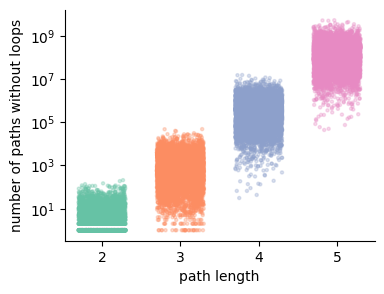

In [41]:
np.random.seed(0)

jitter = 0.3
x = noloop["plen"].to_numpy()
y = noloop["n_paths_noloop"].to_numpy()

x_jittered = x + np.random.uniform(-jitter, jitter, size=len(x))

plt.figure(figsize=(4,3))
plt.scatter(x_jittered, y, alpha=0.3, s=5, c=noloop['plen'].astype(int).map(palette))
plt.xlabel("path length")
plt.ylabel("number of paths without loops")
plt.yscale("log")
# force integer ticks on x-axis
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))

# remove upper and right borders
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.show()


In [42]:
noloop.groupby('plen')['n_paths_noloop'].quantile([0.25, 0.5, 0.75])

plen      
2     0.25    0.000000e+00
      0.50    1.000000e+00
      0.75    4.000000e+00
3     0.25    1.610000e+02
      0.50    5.570000e+02
      0.75    1.794000e+03
4     0.25    8.552525e+04
      0.50    2.616515e+05
      0.75    7.178035e+05
5     0.25    3.965368e+07
      0.50    1.094434e+08
      0.75    2.805549e+08
Name: n_paths_noloop, dtype: float64

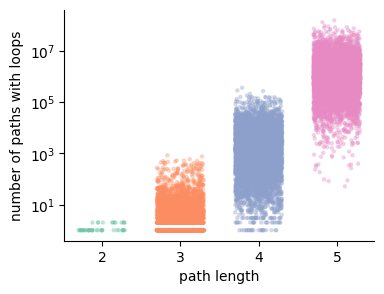

In [43]:
np.random.seed(0)

jitter = 0.3
x = noloop["plen"].to_numpy()
y = noloop["npaths_loop_diff"].to_numpy()

x_jittered = x + np.random.uniform(-jitter, jitter, size=len(x))

plt.figure(figsize=(4,3))
plt.scatter(x_jittered, y, alpha=0.3, s=5, c=noloop['plen'].astype(int).map(palette))
plt.xlabel("path length")
plt.ylabel("number of paths with loops")
plt.yscale("log")
# force integer ticks on x-axis
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))

# remove upper and right borders
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.show()


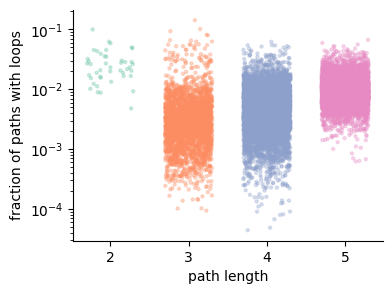

In [44]:
np.random.seed(0)

jitter = 0.3
x = noloop["plen"].to_numpy()
y = noloop["loop_frac"].to_numpy()

x_jittered = x + np.random.uniform(-jitter, jitter, size=len(x))

plt.figure(figsize=(4,3))
plt.scatter(x_jittered, y, alpha=0.3, s=5, c=noloop['plen'].astype(int).map(palette))
plt.xlabel("path length")
plt.ylabel("fraction of paths with loops")
plt.yscale("log")
# force integer ticks on x-axis
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))

# remove upper and right borders
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.show()


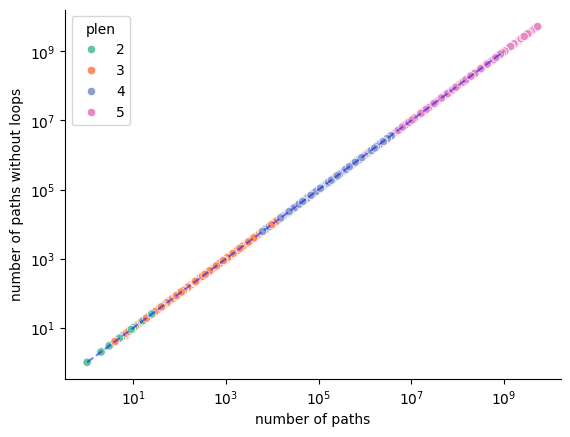

In [45]:
noloop['plen'] = noloop['plen'].astype(str)
noloop["plen"] = pd.Categorical(
    noloop["plen"], 
    categories=["2", "3", "4", "5"], 
    ordered=True
)
# add y=x line
plt.plot([1, 1e9], [1, 1e9], color="blue", linestyle="--", alpha=0.5)
sns.scatterplot(noloop, x="n_paths", y="n_paths_noloop", hue="plen")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("number of paths")
plt.ylabel("number of paths without loops")

# remove upper and right borders
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.show()

In [46]:
# interactive 
px.scatter(noloop, x="n_paths", y="n_paths_noloop", log_y=True, log_x=True, color="plen")

In [47]:
# make longer: all columns starting with 'threshold'
noloop = noloop.melt(id_vars=['plen', 'effconn_noloop', 'effconn','pre','post', 'n_paths'], value_vars=[col for col in noloop.columns if col.startswith('threshold')], var_name='threshold', value_name='value')
noloop['threshold'] = noloop['threshold'].str.replace('threshold_','')
noloop['path_length'] = noloop['plen'].astype(str)
noloop["path_length"] = pd.Categorical(
    noloop["path_length"], 
    categories=["2", "3", "4", "5"], 
    ordered=True
)
noloop

,plen,effconn_noloop,effconn,pre,post,n_paths,threshold,value,path_length
0,2,4.742473e-06,4.742473e-06,DNd04_left,CB0906_right,12,0,True,2
1,3,2.679580e-05,2.679580e-05,DNd04_left,CB0906_right,3544,0,True,3
2,4,4.979766e-05,5.015441e-05,DNd04_left,CB0906_right,881577,0,True,4
3,5,5.979337e-05,6.396395e-05,DNd04_left,CB0906_right,207393098,0,True,5
4,2,1.151613e-04,1.151613e-04,DNd04_left,CB3126_left,30,0,True,2
...,...,...,...,...,...,...,...,...,...
143995,5,2.708529e-07,2.726754e-07,LHPV4a10_right,CB2392_right,6401615,0.1,False,5
143996,2,NaN,NaN,LHPV4a10_right,LHPV10c1_left,0,0.1,False,2
143997,3,1.140800e-05,1.140861e-05,LHPV4a10_right,LHPV10c1_left,877,0.1,False,3
143998,4,1.850830e-05,1.873583e-05,LHPV4a10_right,LHPV10c1_left,457664,0.1,False,4


In [48]:
noloop[['pre','post']].nunique()

pre      60
post    100
dtype: int64

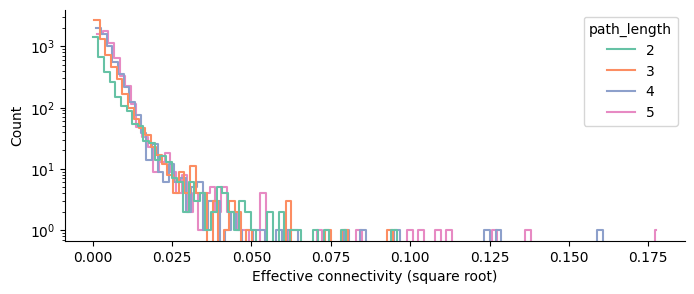

In [49]:
noloop["effconn_noloop_sqrt"] = np.sqrt(noloop["effconn_noloop"])

plt.figure(figsize=(8,3))
sns.histplot(
    data=noloop[(noloop.effconn_noloop.notna()) & (noloop.threshold == '0')],
    x="effconn_noloop_sqrt",
    hue="path_length",
    bins=100,
    multiple="dodge",
    fill=False, 
    element="step",
)
plt.yscale("log")
plt.xlabel("Effective connectivity (square root)")
# remove upper and right borders
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

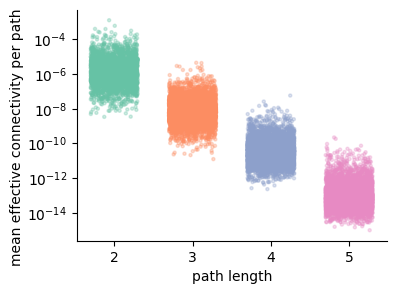

In [50]:
np.random.seed(0)
noloop['effconn_per_path'] = noloop.effconn / noloop.n_paths

jitter = 0.3
x = noloop[noloop.threshold == '0']["plen"].astype(int).to_numpy()
y = noloop[noloop.threshold == '0']["effconn_per_path"].to_numpy()

x_jittered = x + np.random.uniform(-jitter, jitter, size=len(x))

plt.figure(figsize=(4,3))
plt.scatter(x_jittered, y, alpha=0.3, s=5, c=noloop[noloop.threshold == '0']['plen'].astype(int).map(palette))
plt.xlabel("path length")
plt.ylabel("mean effective connectivity per path")
plt.gca().yaxis.set_label_coords(-0.17, 0.45)
plt.yscale("log")
# force integer ticks on x-axis
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))

# remove upper and right borders
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.show()
